# Trajectory and velocity analysis of scRNAseq COLON data 

This is one in the series of notebooks presenting the data analysis done in the study "Widespread epithelial dedifferentiation in patients with ulcerative colitis". It is also intended as a tutorial in scRNAseq analysis. Please refer to the REAMDE file for the description of different parts of the tutorial and how to follow it.  

## Part 1. Data load and quality control

This is the first part of the guide in which we load the data files and perform a throughout quality control of the cells. We discard the cells of low quality (as determined by one of many factors) and very lowly expressed genes. At the end we pack all our sample files into one, so in the the next parts we may work on our whole dataset jointly. If you need help getting your data into the right format or dowloading the packages, please refer to the **Part 0** of this tutorial. 

### Healthy dataset

This notebook shows the pipeline done on the "Healthy dataset" (see study for details regarding samples constituting the dataset). Here I am explaining the procedure step by step, so hopefully one can repeat it on their own data. In this repository there are also notebooks showing the same pipeline for other datasets from the study. I am not repeating the descriptions in those, so please always refer to the "Healthy dataset" notebooks while following the tutorial. 

Here I am working on 4 samples which I want to merge together into one condition - Healthy. You need to adjust the code accordingly to the number of samples/conditions you're working on. 

#### 0. Imports and settings

In [1]:
import scanpy as sc
import scvelo as scv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import scrublet as scr
import doubletdetection

#### 1. Load data

All files are in the `.loom` format. They have been preprcoessed with *cellranger* (demultiplexing, alignment and counting) and *velocyto* (annotation of spliced/unspliced counts). 

After loading in the file, we have to remove some of the unnecssary data fields generated by previous processing. What we want in the end is just the matrix of raw counts, and matrices of spliced and unspliced reads.

In [2]:
sample_name = "healthy1"
file = "data/{}.loom".format(sample_name)
adata1 = scv.read_loom(file, sparse=True, cleanup=True)
adata1.var_names_make_unique()
# Delete obsolite data created by velocyto
del adata1.obs['Clusters']
del adata1.obs['_X']
del adata1.obs['_Y']
del adata1.var['Accession']
del adata1.var['Chromosome']
del adata1.var['End']
del adata1.var['Start']
del adata1.var['Strand']
del adata1.layers['ambiguous']

sample_name = "healthy2"
file = "data/{}.loom".format(sample_name)
adata2 = scv.read_loom(file, sparse=True, cleanup=True)
adata2.var_names_make_unique()
del adata2.obs['Clusters']
del adata2.obs['_X']
del adata2.obs['_Y']
del adata2.var['Accession']
del adata2.var['Chromosome']
del adata2.var['End']
del adata2.var['Start']
del adata2.var['Strand']
del adata2.layers['ambiguous']

sample_name = "healthy3"
file = "data/{}.loom".format(sample_name)
adata3 = scv.read_loom(file, sparse=True, cleanup=True)
adata3.var_names_make_unique()
del adata3.obs['Clusters']
del adata3.obs['_X']
del adata3.obs['_Y']
del adata3.var['Accession']
del adata3.var['Chromosome']
del adata3.var['End']
del adata3.var['Start']
del adata3.var['Strand']
del adata3.layers['ambiguous']

sample_name = "healthy4"
file = "data/{}.loom".format(sample_name)
adata4 = scv.read_loom(file, sparse=True, cleanup=True)
adata4.var_names_make_unique()
del adata4.obs['Clusters']
del adata4.obs['_X']
del adata4.obs['_Y']
del adata4.var['Accession']
del adata4.var['Chromosome']
del adata4.var['End']
del adata4.var['Start']
del adata4.var['Strand']
del adata4.layers['ambiguous']

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


#### 2. Quality control

The first step of the analysis is to filter the cells based on their quality. This will remove dead cells, doublets and other sequencing artifacts. This is necessary as large amount of low quality data points could influence downstream results. 

Quality of a cell can be determined based on a number of metrics:
- number of counts (also unspliced when working with RNA velocity)
- number of genes
- percent of mitochondrail counts 
- percent of ribosomal counts

The last point is not used as a metric here, but can be, depending on the origin of your dataset.

Now we need to decide on a cutoff treshold for each of the parameters. A naive aproach would be to join the samples together first and then set a treshold common to all the samples (for example not more than 5% mito counts per cell). This may be easier, however there may be large differences between the samples in distribution of those quality metrics. In which case it is prefferable to choose filtering gates separately for each of the samples. That way we don't discriminate against any of the samples. 

First thing to do is to inspect the distribution per sample of the common quality metrics. We temporarily merge samples together in order to easier compare the samples. 

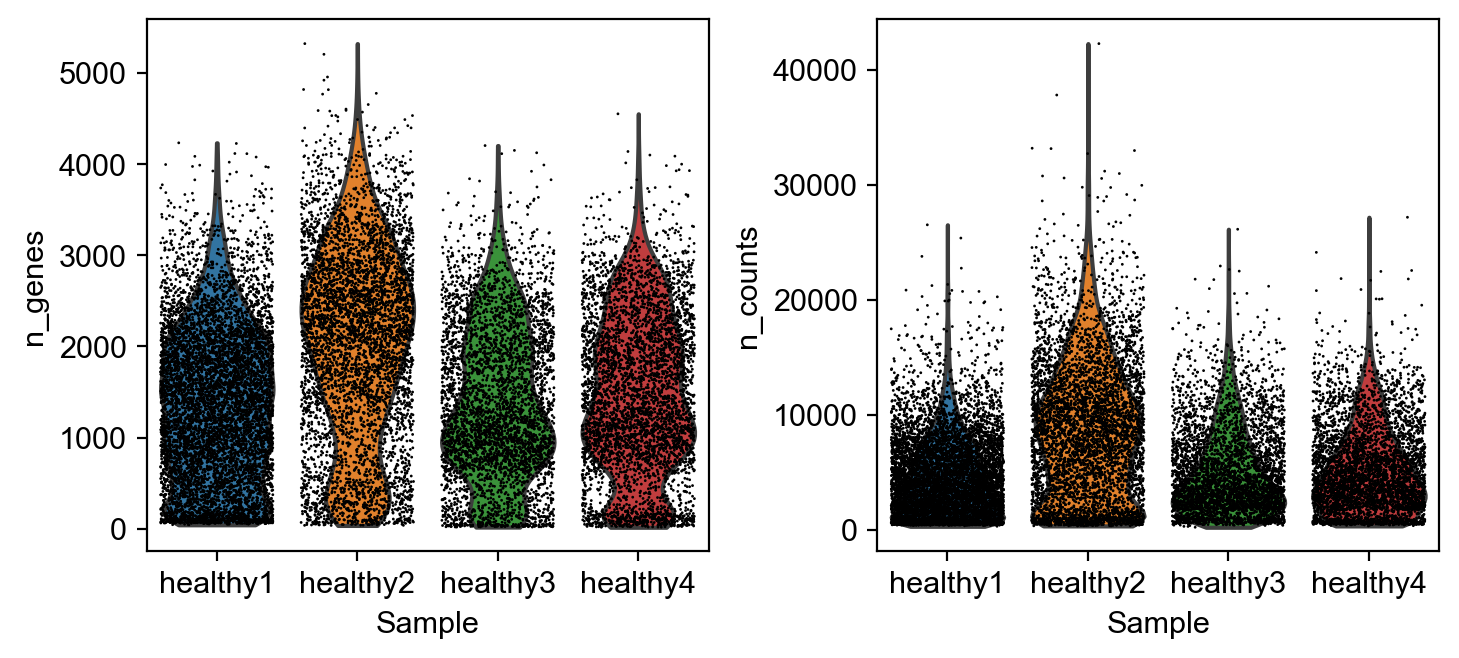

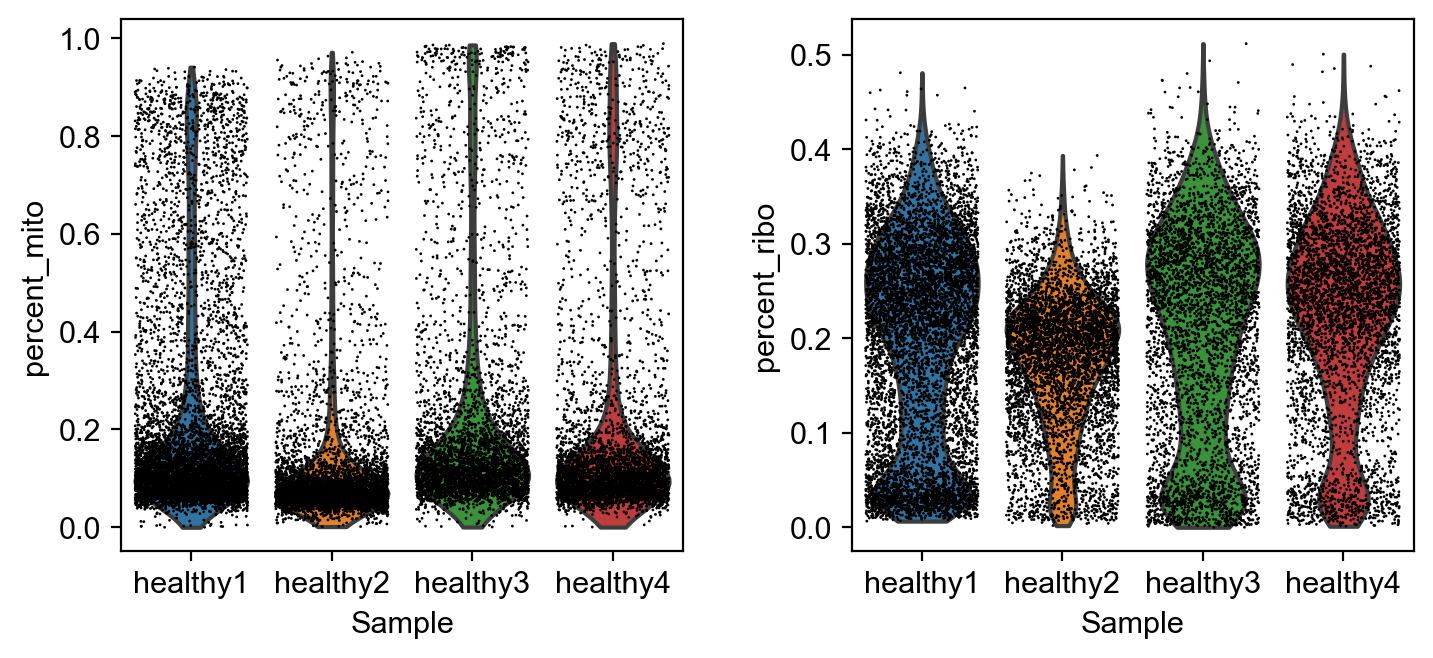

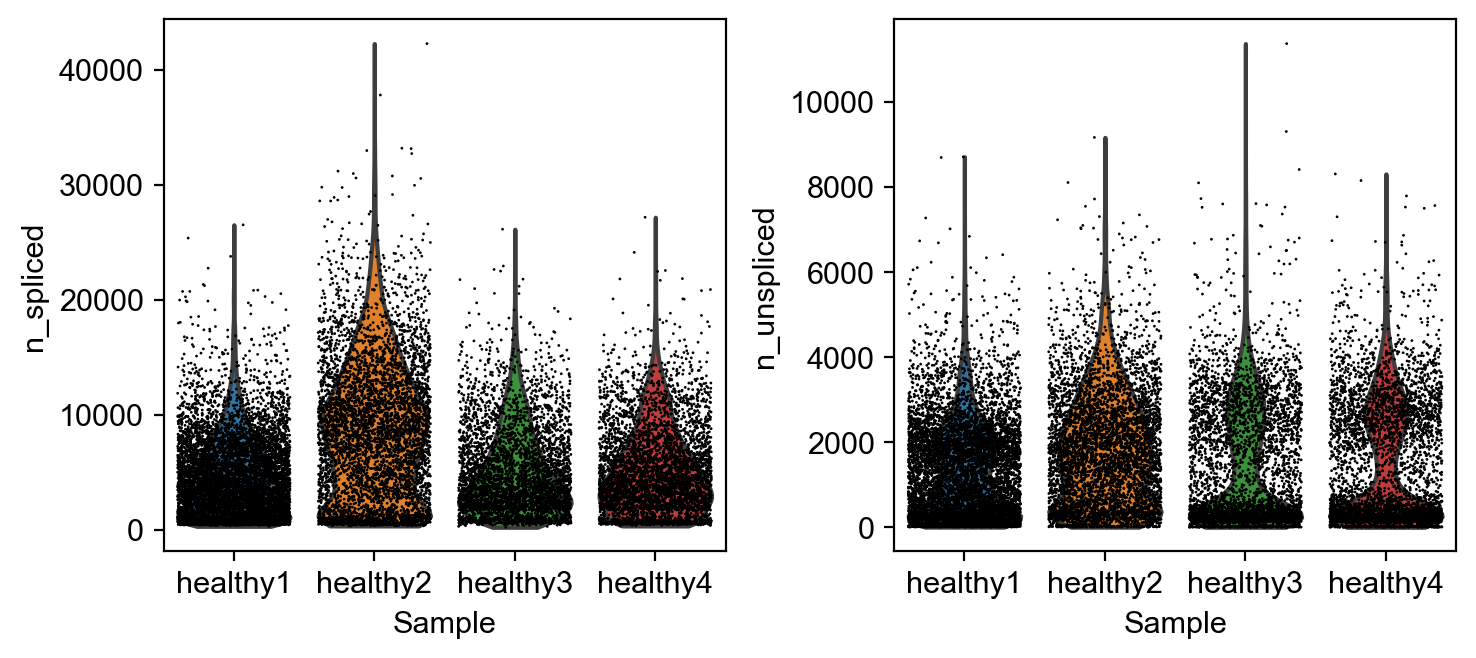

In [18]:
# Concatenate the files to calculate joint QC metrics
adata_qc = adata1.concatenate(adata2, adata3, adata4, 
                              batch_key='Sample', batch_categories=['healthy1', 'healthy2', 'healthy3', 'healthy4'])

# Calculate QC covariates
adata_qc.obs['n_counts'] = adata_qc.X.sum(1)
adata_qc.obs['n_spliced'] = adata_qc.layers['spliced'].sum(1)
adata_qc.obs['n_unspliced'] = adata_qc.layers['unspliced'].sum(1)
adata_qc.obs['n_genes'] = (adata_qc.X > 0).sum(1)
# Compute for each cell the fraction of counts in mitochondrial genes vs. all genes
mito_genes = adata_qc.var_names.str.startswith('MT-')
adata_qc.obs['percent_mito'] = np.sum(
    adata_qc[:, mito_genes].X, axis=1) / np.sum(adata_qc.X, axis=1)
# Compute for each cell the fraction of counts in ribosomal genes vs. all genes
ribo_genes = adata_qc.var_names.str.startswith('RP')
adata_qc.obs['percent_ribo'] = np.sum(
    adata_qc[:, ribo_genes].X, axis=1) / np.sum(adata_qc.X, axis=1)

# Initial plotting settings for more detailed scatter and dist plots.
scv.settings.set_figure_params('scvelo', dpi=100, vector_friendly=True, figsize=[4,3.5])

# Plot the statistics on a violin plot split by sample.
sc.pl.violin(adata_qc, ['n_genes', 'n_counts'], jitter=0.4, groupby='Sample')
sc.pl.violin(adata_qc, ['percent_mito', 'percent_ribo'], jitter=0.4, groupby='Sample')
sc.pl.violin(adata_qc, ['n_spliced', 'n_unspliced'], jitter=0.4, groupby='Sample')

As we can see in the figure above, there are significant differences in the distributions of quality metrics in the four samples. That is why we need to adjust the filtering thresholds per sample. 

##### 2.1 healthy1

We begin with the sample *healthy1*. First, we calculate and visualise the quality metrics again, this time focusing on the single sample.

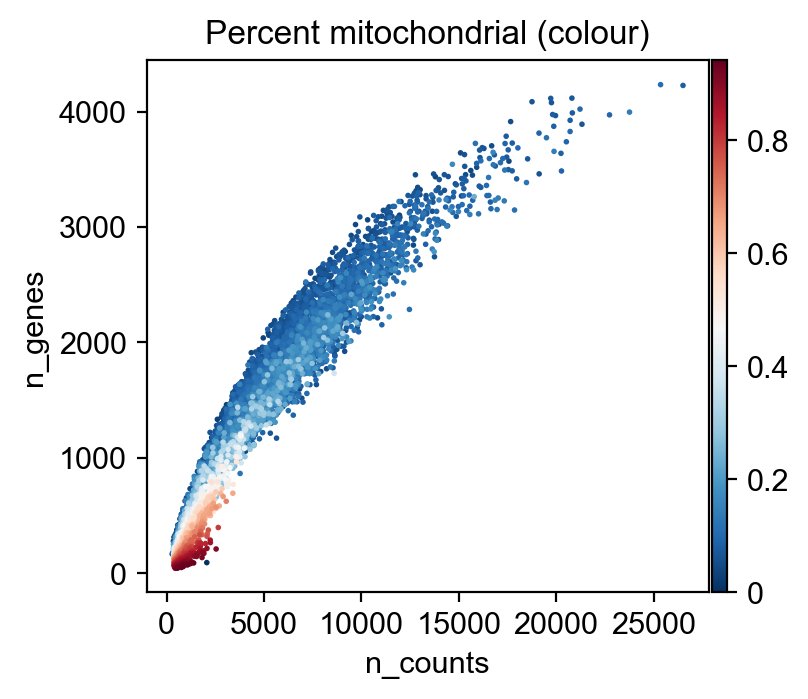

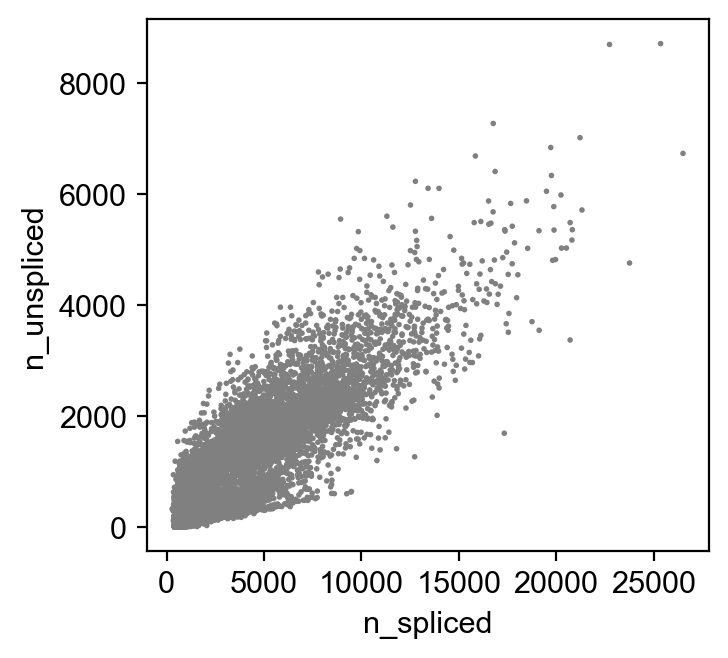

In [17]:
# Calculate QC covariates
adata1.obs['n_counts'] = adata1.X.sum(1)
adata1.obs['log_counts'] = np.log(adata1.obs['n_counts'])
adata1.obs['n_spliced'] = adata1.layers['spliced'].sum(1)
adata1.obs['n_unspliced'] = adata1.layers['unspliced'].sum(1)
adata1.obs['n_genes'] = (adata1.X > 0).sum(1)
# Compute for each cell the fraction of counts in mito genes vs. all genes
mito_genes = adata1.var_names.str.startswith('MT-')
adata1.obs['percent_mito'] = np.sum(
    adata1[:, mito_genes].X, axis=1) / np.sum(adata1.X, axis=1)
# Compute for each cell the fraction of counts in ribosomal genes vs. all genes
ribo_genes = adata1.var_names.str.startswith('RP')
adata1.obs['percent_ribo'] = np.sum(
    adata1[:, ribo_genes].X, axis=1) / np.sum(adata1.X, axis=1)

# Decrease the size of plots
scv.settings.set_figure_params('scvelo', dpi=100, vector_friendly=True, figsize=[4,3.5])

sc.pl.scatter(adata1, 'n_counts', 'n_genes', color='percent_mito', title='Percent mitochondrial (colour)')
sc.pl.scatter(adata1, 'n_spliced', 'n_unspliced')

There is a strong correlation between the number of counts, genes and the mitochondrial content, however, it is still important to look at those statistics jointly. There are many outliers (high number of counts, low number of genes). Specifically, we can see cells with many genes (likely not dead) that have a high mitochondrial content (around 50%). This means we cannot simply exclude all the cells with more than 5% mito content.

Looking at the second we can see the see the relation between the number of spliced and unspliced counts. Importantly, a number of cells have a notably lower amount of unspliced counts compared to the spliced ones. Normally those cells would be fine to keep, but in the case when we are working with RNA velocity, a cell with low number of unspliced counts can negatively imapct the results. We will remove some of those cells in a moment.  

It is also important to consider single results from the perspective of the entire population. In this example we can see a few cells with a very high number of counts - over 2 times larger than average. Even though in a different dataset those cells could be fine, here we consider them as outliers, probably doublets (two cells sequenced together). 

Presence of doublets in the dataset can be infered. Here we do it with two tools - `scrublet` and `DoubletDetection`. It is important to detect the doublets **before** we remove any of the low quality cells, as the tools need a full picture of the dataset to work properly. 

First we use the tooll called `scrublet` to identify doublets - two cells barcoded togheter. Especially important when we are trying too identify cells transitioning between celltypes. We use scrublet to assign doublet score (probability of being a doublet).

The parameters should be fine by defualt, but you may want/need to adjust them. Please refer to the [official documentation](https://github.com/AllonKleinLab/scrublet/blob/master/examples/scrublet_basics.ipynb).

In [ ]:
# Doublet analysis
scrub = scr.Scrublet(adata1.X, expected_doublet_rate=0.06)
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30,
                                                          mean_center=False, 
                                                          normalize_variance=False,
                                                          log_transform=True)

`scrublet` simulates doublets by artifically combining cells from the dataset and then assigns a doublet score to both (observed cells and simulated doublet cells). Based on those it sets a treshold at doublet score to predict doublets. We can compare those results in a histogram. 

In [ ]:
scrub.plot_histogram()

We can also quickly plot the doublets on a UMAP plot to see that they cluster together. 

In [ ]:
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True)

Looking at the cells in clusters with high doublet score we can assume there are probably more doublets than only those predicted by `scrublet`. Later we will see similar results comparing them with the next tool. It is therefore better to filter out the doublets ourselves based on the score. 

We assign the doublet score to a variable in the `adata` object.

In [ ]:
adata1.obs['doublet_score'] = scrub.doublet_scores_obs_

Another tool to annotate doublets is `DoubletDetection`. More sophisticated, uses machine learning, but takes a **long** time to run (5-10 min).  Uses a classsifier and does not need us to supply a cut-off value for being a doublet. 

Removing cells annotated as doublets by those two tools ensures our later results are not affected by those technical errors. 

In [ ]:
clf = doubletdetection.BoostClassifier(n_iters=50, use_phenograph=False, standard_scaling=True)
doublets = clf.fit(adata1.X).predict(p_thresh=1e-16, voter_thresh=0.5)

We can see how the number of predicted doublets changes per iteration of the algorithm as the doublet prediction threshold is refined. 

In [ ]:
f = doubletdetection.plot.convergence(clf, show=True, p_thresh=1e-16, voter_thresh=0.5)

Again, we can plot the predicted doublets on a umap plot.

In [ ]:
f2, umap_coords = doubletdetection.plot.umap_plot(adata1.X, doublets, random_state=1, show=True)

Now we add the predicted doublets as another variable.

In [ ]:
adata1.obs['doublet'] = list(map(str, map(int, doublets)))

Next, we look at distribution plots of **count** statistics to set thresholds for **cell filtering**. 

In [ ]:
# Thresholding decision: spliced counts
ax=sb.distplot(adata1.obs['n_spliced'], kde=False)
plt.show()

# Closer look at lower treshold
ax=sb.distplot(adata1.obs['n_spliced'][adata1.obs['n_spliced']<3500], kde=False, bins=60)
plt.show()

# Closer look at upper treshold
ax=sb.distplot(adata1.obs['n_spliced'][adata1.obs['n_spliced']>15000], kde=False, bins=60)
plt.show()

Statistically, the distribution of counts we observe should approach a Gaussian (normal) distribution. By visually tracing the characteristic bell-shaped curve, we can approximate the cut-off threshold for high quality cells. We do it both for data points with too few or too many counts. The first occur e.g. when debree is sequnced rather than full cells, and the latter are two (or more) cells sequenced at once. 

In this case we can see that the lower cut-off should be somewhere between 1000 and 1500 cells and the upper cut-off should be around 18000 counts. You can make more plots with different level of "zoom" to determine the values more precise. 

In a similar fashion we now look at the unspliced counts.

In [ ]:
#Thresholding decision: unspliced counts
ax=sb.distplot(adata1.obs['n_unspliced'], kde=False)
plt.show()

ax=sb.distplot(adata1.obs['n_unspliced'][adata1.obs['n_unspliced']<2000], kde=False, bins=60)
plt.show()

Too many unspliced counts shouldn't be an issue on its own, so we only look at the lower threshold. 

This time the curve shape is not as obvious to follow. We stay on the permissive side and set the cut-off the 600.

Finally, we look at distribution of the number of genes per cell to set the final gate for cell filtering.

In [ ]:
#Thresholding decision: genes
ax=sb.distplot(adata1.obs['n_genes'], kde=False, bins=60)
plt.show()
ax=sb.distplot(adata1.obs['n_genes'][adata1.obs['n_genes']<1000], kde=False, bins=60)
plt.show()

Now we apply the estimated limits and filter out low quality cells. 

In [ ]:
print("Cells before filtering: ", len(adata1.obs_names), "\n")

sc.pp.filter_cells(adata1, min_counts=1250)
sc.pp.filter_cells(adata1, max_counts=18750)
adata1 = adata1[adata1.obs['n_unspliced']>600]
sc.pp.filter_cells(adata1, min_genes=250)

print("Cells after filtering: ", len(adata1.obs_names))

Based on count statistics alone we got rid off almost 3000 cells.

The distribution of genes and counts is now much more balanced.

In [ ]:
sc.pl.violin(adata1, ['n_genes', 'n_counts', 'percent_mito'],
             jitter=0.4, multi_panel=True)

Let's now focus on the the mitochondrial gene content and compare it with the general number of genes.

In [ ]:
sc.pl.scatter(adata1, 'n_genes', 'percent_mito')

In general, the mitochondrial gene content is quite high across all the cells in the sample and since we want to capture the majority of the population, we set the limit to 30%. That is a high amount, however, those cells still have a lot of genes, which suggests that they are alive and biologically relevant. This is why, in this case, we should be permissive with our treshold. 

This step very much depends on the origin of your dataset. Intestinal epithelium is known to have a high mitochondrial activity, so being lenient with the threshold makes sense biologically. If your sample is from a different tissue, you need to adjust accordingly. 

In [ ]:
adata1 = adata1[adata1.obs['percent_mito'] < 0.3, :]
sc.pl.scatter(adata1, 'n_counts', 'n_genes', color='percent_mito', title='Percent mitochondrial genes')
print(adata1)

Finally, we filter out the remaining doublet cells. For this we use the results from `scrublet` and `DoubletDetection` methods. We compare the agreement between the two methods we used by visualising their scores together. 

In [ ]:
sc.pl.scatter(adata1, 'n_genes', 'doublet_score', color='doublet', palette=['gray', 'orange'], legend_loc='none', title='')

In the plot above y-axis shows the doublet score from `scrublet` and the point are coloured by their classification from `DoubletDetection` (orange means doublet). 

We can see that some cells that scored very highly in scrublet are not classified as doublets by the other software. Those may be false negatives, so we filter them out as well to be sure we don't have any doublets. This is done at the cost of filtering out some false positives. However, the assumption is that the cell populations we are interested in are common enough that they would not be affected. 

It is also perfectly acceptable to only filter based on one of the tools. You may use only `scrublet`, since it's faster, or only `DoubletDetection`, since it's supposed to be more accurate. The bottom line is, you should take some actions to ensure there are no doublets in your dataset. 

In [ ]:
adata1 = adata1[adata1.obs['doublet'] != '1']
adata1 = adata1[adata1.obs['doublet_score'] < 0.3]

In [ ]:
print(adata1)

As you can see, in the end we are left with just short of 4000 cells (after starting with over 7000). But we now know those 4k cells are of good quality and will provide realiable results. 

We can also look at the highest expressed genes in the dataset. A lot of them are mitochondrial, ribosomal or housekeeping genes. We will filter them out at a later stage, after combining the samples. 

In [ ]:
sc.pl.highest_expr_genes(adata1, n_top=20)

##### 2.2 healthy2

The analysis and its reasoning is analogous to the previous one. See section **2.1** for describtion.

In [ ]:
# Calculate QC covariates
adata2.obs['n_counts'] = adata2.X.sum(1)
adata2.obs['log_counts'] = np.log(adata2.obs['n_counts'])
adata2.obs['n_genes'] = (adata2.X > 0).sum(1)
adata2.obs['n_spliced'] = adata2.layers['spliced'].sum(1)
adata2.obs['n_unspliced'] = adata2.layers['unspliced'].sum(1)
# Compute for each cell the fraction of counts in mito genes vs. all genes
mito_genes = adata2.var_names.str.startswith('MT-')
adata2.obs['percent_mito'] = np.sum(
    adata2[:, mito_genes].X, axis=1) / np.sum(adata2.X, axis=1)
# Compute for each cell the fraction of counts in ribosomal genes vs. all genes
ribo_genes = adata2.var_names.str.startswith('RP')
adata2.obs['percent_ribo'] = np.sum(
    adata2[:, ribo_genes].X, axis=1) / np.sum(adata2.X, axis=1)

sc.pl.scatter(adata2, 'n_counts', 'n_genes', color='percent_mito', title='Percent mitochondrial genes')
sc.pl.scatter(adata2, 'n_spliced', 'n_unspliced')

In [ ]:
# Doublet analysis
scrub = scr.Scrublet(adata2.X, expected_doublet_rate=0.06)
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30,
                                                          mean_center=False, 
                                                          normalize_variance=False,
                                                          log_transform=True)

In [ ]:
scrub.plot_histogram()

In [ ]:
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True)

In [ ]:
adata2.obs['doublet_score'] = scrub.doublet_scores_obs_

In [ ]:
clf = doubletdetection.BoostClassifier(n_iters=50, use_phenograph=False, standard_scaling=True)
doublets = clf.fit(adata2.X).predict(p_thresh=1e-16, voter_thresh=0.5)

In [ ]:
f = doubletdetection.plot.convergence(clf, show=True, p_thresh=1e-16, voter_thresh=0.5)

In [ ]:
f2, umap_coords = doubletdetection.plot.umap_plot(adata2.X, doublets, random_state=1, show=True)

In [ ]:
adata2.obs['doublet'] = list(map(str, map(int, doublets)))

In [ ]:
# Thresholding decision: spliced counts
ax=sb.distplot(adata2.obs['n_spliced'], kde=False)
plt.show()

ax=sb.distplot(adata2.obs['n_spliced'][adata2.obs['n_spliced']<4000], kde=False, bins=60)
plt.show()

ax=sb.distplot(adata2.obs['n_spliced'][adata2.obs['n_spliced']>20000], kde=False, bins=60)
plt.show()

In [ ]:
# Thresholding decision: unspliced counts
ax=sb.distplot(adata2.obs['n_unspliced'], kde=False)
plt.show()

ax=sb.distplot(adata2.obs['n_unspliced'][adata2.obs['n_unspliced']<1750], kde=False, bins=60)
plt.show()

In [ ]:
# Thresholding decision: genes
ax=sb.distplot(adata2.obs['n_genes'], kde=False, bins=60)
plt.show()
ax=sb.distplot(adata2.obs['n_genes'][adata2.obs['n_genes']<1750], kde=False, bins=60)
plt.show()

In [ ]:
print("Cells before filtering: ", len(adata2.obs_names), "\n")

sc.pp.filter_cells(adata2, min_counts=2100)
sc.pp.filter_cells(adata2, max_counts=26000)
adata2 = adata2[adata2.obs['n_unspliced']>700]
sc.pp.filter_cells(adata2, min_genes=900)

print("Cells after filtering: ", len(adata2.obs_names))

In [ ]:
sc.pl.violin(adata2, ['n_genes', 'n_counts', 'percent_mito'],
             jitter=0.4, multi_panel=True)

In [ ]:
sc.pl.scatter(adata2, 'n_genes', 'percent_mito')

In [ ]:
adata2 = adata2[adata2.obs['percent_mito'] < 0.3, :]
sc.pl.scatter(adata2, 'n_counts', 'n_genes', color='percent_mito', title='Percent mitochondrial genes')
print(adata2)

In [ ]:
sc.pl.scatter(adata2, 'n_genes', 'doublet_score', color='doublet', palette=['gray', 'orange'], legend_loc='none', title='Doublet')
adata2 = adata2[adata2.obs['doublet'] != '1']
adata2 = adata2[adata2.obs['doublet_score'] < 0.3]

In [ ]:
print(adata2)
sc.pl.highest_expr_genes(adata2, n_top=20)

##### 2.3 healthy3

The analysis and its reasoning is analogous to the previous one. See section **2.1** for describtion.

In [ ]:
# Calculate QC covariates
adata3.obs['n_counts'] = adata3.X.sum(1)
adata3.obs['log_counts'] = np.log(adata3.obs['n_counts'])
adata3.obs['n_genes'] = (adata3.X > 0).sum(1)
adata3.obs['n_spliced'] = adata3.layers['spliced'].sum(1)
adata3.obs['n_unspliced'] = adata3.layers['unspliced'].sum(1)
# Compute for each cell the fraction of counts in mito genes vs. all genes
mito_genes = adata3.var_names.str.startswith('MT-')
adata3.obs['percent_mito'] = np.sum(
    adata3[:, mito_genes].X, axis=1) / np.sum(adata3.X, axis=1)
# Compute for each cell the fraction of counts in ribosomal genes vs. all genes
ribo_genes = adata3.var_names.str.startswith('RP')
adata3.obs['percent_ribo'] = np.sum(
    adata3[:, ribo_genes].X, axis=1) / np.sum(adata3.X, axis=1)

sc.pl.scatter(adata3, 'n_counts', 'n_genes', color='percent_mito', title='Percent mitochondrial genes')
sc.pl.scatter(adata3, 'n_spliced', 'n_unspliced')

In [ ]:
# Doublet analysis
scrub = scr.Scrublet(adata3.X, expected_doublet_rate=0.06)
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30,
                                                          mean_center=False, 
                                                          normalize_variance=False,
                                                          log_transform=True)

In [ ]:
scrub.plot_histogram()

In [ ]:
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True)

In [ ]:
adata3.obs['doublet_score'] = scrub.doublet_scores_obs_

In [ ]:
clf = doubletdetection.BoostClassifier(n_iters=50, use_phenograph=False, standard_scaling=True)
doublets = clf.fit(adata3.X).predict(p_thresh=1e-16, voter_thresh=0.5)

In [ ]:
f = doubletdetection.plot.convergence(clf, show=True, p_thresh=1e-16, voter_thresh=0.5)

In [ ]:
f2, umap_coords = doubletdetection.plot.umap_plot(adata3.X, doublets, random_state=1, show=True)

In [ ]:
adata3.obs['doublet'] = list(map(str, map(int, doublets)))

In [ ]:
# Thresholding decision: spliced counts
ax=sb.distplot(adata3.obs['n_spliced'], kde=False)
plt.show()

ax=sb.distplot(adata3.obs['n_spliced'][adata3.obs['n_spliced']<2500], kde=False, bins=60)
plt.show()

ax=sb.distplot(adata3.obs['n_spliced'][adata3.obs['n_spliced']>12500], kde=False, bins=60)
plt.show()

In [ ]:
# Thresholding decision: unspliced counts
ax=sb.distplot(adata3.obs['n_unspliced'], kde=False)
plt.show()

ax=sb.distplot(adata3.obs['n_unspliced'][adata3.obs['n_unspliced']<1500], kde=False, bins=60)
plt.show()

In [ ]:
# Thresholding decision: genes
ax=sb.distplot(adata3.obs['n_genes'], kde=False, bins=60)
plt.show()
ax=sb.distplot(adata3.obs['n_genes'][adata3.obs['n_genes']<1000], kde=False, bins=60)
plt.show()

In [ ]:
print("Cells before filtering: ", len(adata3.obs_names), "\n")

sc.pp.filter_cells(adata3, min_counts=1600)
sc.pp.filter_cells(adata3, max_counts=18000)
adata3 = adata3[adata3.obs['n_unspliced']>750]
sc.pp.filter_cells(adata3, min_genes=500)

print("Cells after filtering: ", len(adata3.obs_names))

In [ ]:
sc.pl.violin(adata3, ['n_genes', 'n_counts', 'percent_mito'],
             jitter=0.4, multi_panel=True)

In [ ]:
sc.pl.scatter(adata3, 'n_genes', 'percent_mito')

In [ ]:
adata3 = adata3[adata3.obs['percent_mito'] < 0.3, :]
sc.pl.scatter(adata3, 'n_counts', 'n_genes', color='percent_mito', title='Percent mitochondrial genes)')
print(adata3)

In [ ]:
sc.pl.scatter(adata3, 'n_genes', 'doublet_score', color='doublet', palette=['gray', 'orange'], legend_loc='none', title='Doublet')
adata3 = adata3[adata3.obs['doublet'] != '1']
adata3 = adata3[adata3.obs['doublet_score'] < 0.3]

In [ ]:
print(adata3)
sc.pl.highest_expr_genes(adata3, n_top=20)

##### 2.4 healthy4

The analysis and its reasoning is analogous to the previous one. See section **2.1** for describtion.

In [ ]:
# Calculate QC covariates
adata4.obs['n_counts'] = adata4.X.sum(1)
adata4.obs['log_counts'] = np.log(adata4.obs['n_counts'])
adata4.obs['n_genes'] = (adata4.X > 0).sum(1)
adata4.obs['n_spliced'] = adata4.layers['spliced'].sum(1)
adata4.obs['n_unspliced'] = adata4.layers['unspliced'].sum(1)
# Compute for each cell the fraction of counts in mito genes vs. all genes
mito_genes = adata4.var_names.str.startswith('MT-')
adata4.obs['percent_mito'] = np.sum(
    adata4[:, mito_genes].X, axis=1) / np.sum(adata4.X, axis=1)
# Compute for each cell the fraction of counts in ribosomal genes vs. all genes
ribo_genes = adata4.var_names.str.startswith('RP')
adata4.obs['percent_ribo'] = np.sum(
    adata4[:, ribo_genes].X, axis=1) / np.sum(adata4.X, axis=1)

sc.pl.scatter(adata4, 'n_counts', 'n_genes', color='percent_mito', title='Percent mitochondrial genes')
sc.pl.scatter(adata4, 'n_spliced', 'n_unspliced')

In [ ]:
# Doublet analysis
scrub = scr.Scrublet(adata4.X, expected_doublet_rate=0.06)
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30,
                                                          mean_center=False, 
                                                          normalize_variance=False,
                                                          log_transform=True)

In [ ]:
scrub.plot_histogram()

In [ ]:
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True)

In [ ]:
adata4.obs['doublet_score'] = scrub.doublet_scores_obs_

In [ ]:
clf = doubletdetection.BoostClassifier(n_iters=50, use_phenograph=False, standard_scaling=True)
doublets = clf.fit(adata4.X).predict(p_thresh=1e-16, voter_thresh=0.5)

In [ ]:
f = doubletdetection.plot.convergence(clf, show=True, p_thresh=1e-16, voter_thresh=0.5)

In [ ]:
f2, umap_coords = doubletdetection.plot.umap_plot(adata4.X, doublets, random_state=1, show=True)

In [ ]:
adata4.obs['doublet'] = list(map(str, map(int, doublets)))

In [ ]:
# Thresholding decision: spliced counts
ax=sb.distplot(adata4.obs['n_spliced'], kde=False)
plt.show()

ax=sb.distplot(adata4.obs['n_spliced'][adata4.obs['n_spliced']<2500], kde=False, bins=60)
plt.show()

ax=sb.distplot(adata4.obs['n_spliced'][adata4.obs['n_spliced']>10000], kde=False, bins=60)
plt.show()

In [ ]:
# Thresholding decision: unspliced counts
ax=sb.distplot(adata4.obs['n_unspliced'], kde=False)
plt.show()

ax=sb.distplot(adata4.obs['n_unspliced'][adata4.obs['n_unspliced']<1500], kde=False, bins=60)
plt.show()

In [ ]:
#Thresholding decision: genes
ax=sb.distplot(adata4.obs['n_genes'], kde=False, bins=60)
plt.show()
ax=sb.distplot(adata4.obs['n_genes'][adata4.obs['n_genes']<1000], kde=False, bins=60)
plt.show()

In [ ]:
print("Cells before filtering: ", len(adata4.obs_names), "\n")

sc.pp.filter_cells(adata4, min_counts=1600)
sc.pp.filter_cells(adata4, max_counts=16000)
adata4 = adata4[adata4.obs['n_unspliced']>800]
sc.pp.filter_cells(adata4, min_genes=500)

print("Cells after filtering: ", len(adata4.obs_names))

In [ ]:
sc.pl.violin(adata4, ['n_genes', 'n_counts', 'percent_mito'],
             jitter=0.4, multi_panel=True)

In [ ]:
sc.pl.scatter(adata4, 'n_genes', 'percent_mito')

In [ ]:
adata4 = adata4[adata4.obs['percent_mito'] < 0.3, :]
sc.pl.scatter(adata4, 'n_counts', 'n_genes', color='percent_mito', title='Percent mitochondrial genes')
print(adata4)

In [ ]:
sc.pl.scatter(adata4, 'n_genes', 'doublet_score', color='doublet', palette=['gray', 'orange'], legend_loc='none', title='Doublet')
adata4 = adata4[adata4.obs['doublet'] != '1']
adata4 = adata4[adata4.obs['doublet_score'] < 0.3]

In [ ]:
print(adata4)
sc.pl.highest_expr_genes(adata4, n_top=20)

#### 3. Merge samples

For the rest of the analysis we concatenate the samples into one object: `adata`. In the next step will normalise and batch correct the data. For now, the last thing we do in this part of the tutorial is gene filtering.

In [ ]:
adata = adata1.concatenate(adata2, adata3, adata4,
                           batch_key='Sample', 
                           batch_categories=['healthy1', 'healthy2', 'healthy3', 'healthy4'])
# Apply workaround necessary due to bugs in code
adata.layers['spliced'] = adata.layers['spliced'].astype(float)
adata.layers['unspliced'] = adata.layers['unspliced'].astype(float)

# Filter out genes expressed in less than 5 cells
scv.pp.filter_genes(adata, min_cells=5)
# Filter out genes with less than 20 counts across all cells
scv.pp.filter_genes(adata, min_counts=20)

adata

For gene filtering we apply two rules to get rid off genes expressed in too few cells or with too few counts. This is done for two reasons:
- decrease the size of the object and speed up subsequent calculations,
- make sure uninformative genes don't influence the results. 

We do the filtering on the joint object to save genes expressed lowly across multiple samples.

#### 4.Save data for the next step 

Saving data with a unique name after each step will prevent overwriting. That means you will always be able to easily come back to a previous step in the pipeline without the need to run everything over again. This is good for the first time trying this pipeline in case something breaks along the way. However, in the future, you may prefer to save to a single file in order to reduce disk space usage. 

In [ ]:
adata.write("healthy_qc.h5ad")